# Exploring the LUNA16 Dataset

This notebook explores the structure and properties of the LUNA16 dataset before implementing the preprocessing pipeline.

**Goals**

- Load a CT volume.
- Study image metadata.
- Understand voxel spacing.
- Visualize CT slices.
- Prepare for patch extraction.

In [1]:
from pathlib import Path

import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "LUNA16"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

# Create output directory if it does not exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)

Project root: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn
Data directory: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16
Figures directory: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures


## Step 1 — Locate CT Volumes

The LUNA16 dataset contains CT scans stored as MetaImage files (`.mhd` and `.raw`).

In this step we search for all available CT volumes.

In [2]:
# Find all LUNA16 CT header files
mhd_files = sorted(DATA_DIR.rglob("*.mhd"))

print("Number of .mhd files:", len(mhd_files))

for path in mhd_files[:5]:
    print(path)

Number of .mhd files: 356
/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd
/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd
/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059.mhd
/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674661221381920536987.mhd
/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896761494371822656720.mhd


## Step 2 — Load the First CT Scan

We load one CT volume using SimpleITK and inspect its metadata.

In [3]:
# Select the first CT scan
ct_path = mhd_files[0]

# Read CT image
image = sitk.ReadImage(str(ct_path))

# Convert to NumPy array
ct_array = sitk.GetArrayFromImage(image)

print("CT path:", ct_path)
print("SimpleITK size (x, y, z):", image.GetSize())
print("NumPy shape (z, y, x):", ct_array.shape)
print("Spacing (x, y, z):", image.GetSpacing())
print("Origin (x, y, z):", image.GetOrigin())
print("Direction:", image.GetDirection())
print("Min HU:", ct_array.min())
print("Max HU:", ct_array.max())
print("Mean HU:", ct_array.mean())

CT path: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd
SimpleITK size (x, y, z): (512, 512, 121)
NumPy shape (z, y, x): (121, 512, 512)
Spacing (x, y, z): (0.7617189884185791, 0.7617189884185791, 2.5)
Origin (x, y, z): (-198.100006, -195.0, -335.209991)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Min HU: -3024
Max HU: 2103
Mean HU: -1035.6235232077354


## Step 3 — Visualize an Axial Slice

The CT volume is converted into a NumPy array.

The middle axial slice is displayed using the lung window.

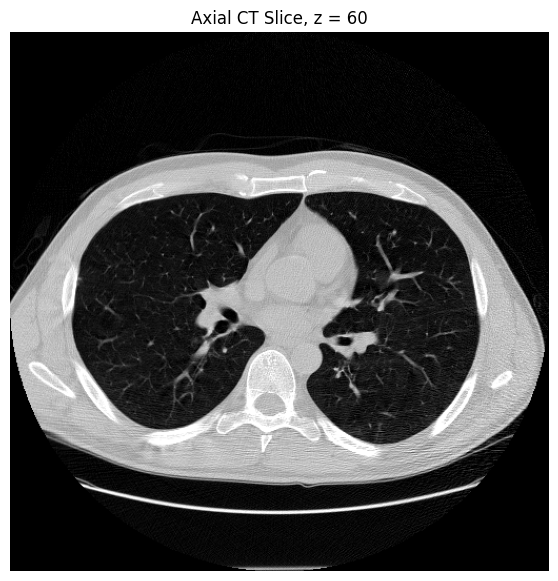

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/first_ct_slice.png


In [6]:
# Select middle axial slice
z_index = ct_array.shape[0] // 2
slice_2d = ct_array[z_index]

# Output file
output_path = FIGURES_DIR / "first_ct_slice.png"

# Save CT slice
plt.figure(figsize=(7, 7))
plt.imshow(slice_2d, cmap="gray", vmin=-1000, vmax=400)
plt.title(f"Axial CT Slice, z = {z_index}")
plt.axis("off")
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", output_path)

# Step 4 — Understanding the CT Volume

A CT scan is a three-dimensional volume.

After converting the image to a NumPy array, the dimensions are ordered as:

(z, y, x)

where:

- z — slice index
- y — image row
- x — image column

In [7]:
# Explore CT volume dimensions

num_slices = ct_array.shape[0]
height = ct_array.shape[1]
width = ct_array.shape[2]

print(f"Number of slices : {num_slices}")
print(f"Slice height     : {height}")
print(f"Slice width      : {width}")

print()
print("Array indexing order:")
print("ct_array[z, y, x]")

Number of slices : 121
Slice height     : 512
Slice width      : 512

Array indexing order:
ct_array[z, y, x]


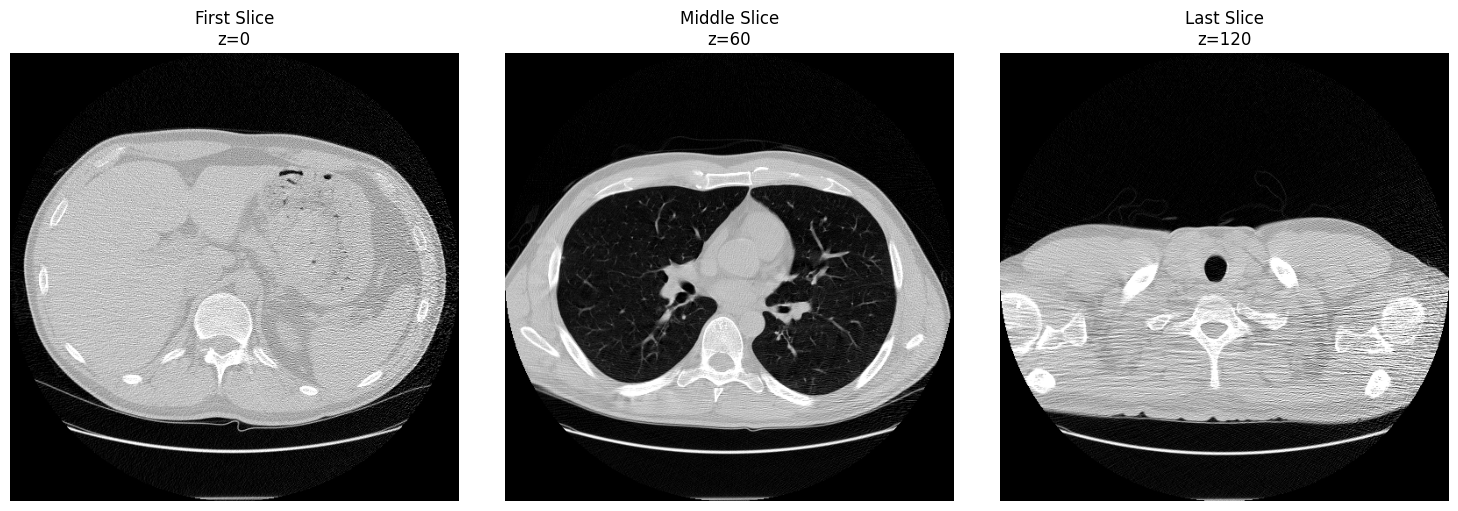

Saved: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/three_axial_slices.png


In [8]:
# Select representative slices

z_first = 0
z_middle = ct_array.shape[0] // 2
z_last = ct_array.shape[0] - 1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ct_array[z_first], cmap="gray", vmin=-1000, vmax=400)
axes[0].set_title(f"First Slice\nz={z_first}")
axes[0].axis("off")

axes[1].imshow(ct_array[z_middle], cmap="gray", vmin=-1000, vmax=400)
axes[1].set_title(f"Middle Slice\nz={z_middle}")
axes[1].axis("off")

axes[2].imshow(ct_array[z_last], cmap="gray", vmin=-1000, vmax=400)
axes[2].set_title(f"Last Slice\nz={z_last}")
axes[2].axis("off")

plt.tight_layout()

output_path = FIGURES_DIR / "three_axial_slices.png"

plt.savefig(output_path, dpi=200)

plt.show()

print("Saved:", output_path)

## Step 5 — Visualize Orthogonal Views

A CT scan is a three-dimensional volume.

Different anatomical planes can be obtained by fixing one coordinate:

- Axial: fix **z**
- Coronal: fix **y**
- Sagittal: fix **x**

These three views are commonly used by radiologists.

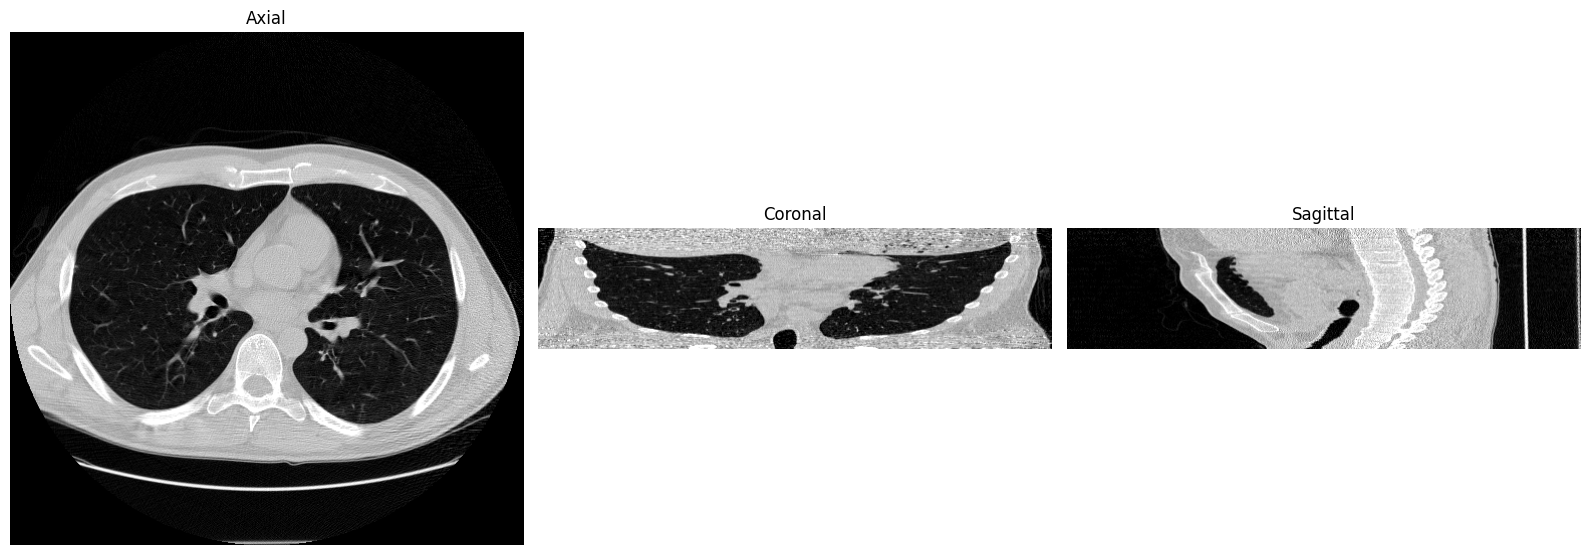

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/orthogonal_views.png


In [9]:
# Select middle indices
z = ct_array.shape[0] // 2
y = ct_array.shape[1] // 2
x = ct_array.shape[2] // 2

# Extract orthogonal slices
axial = ct_array[z, :, :]
coronal = ct_array[:, y, :]
sagittal = ct_array[:, :, x]

# Display slices
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(axial, cmap="gray", vmin=-1000, vmax=400)
axes[0].set_title("Axial")
axes[0].axis("off")

axes[1].imshow(coronal, cmap="gray", vmin=-1000, vmax=400)
axes[1].set_title("Coronal")
axes[1].axis("off")

axes[2].imshow(sagittal, cmap="gray", vmin=-1000, vmax=400)
axes[2].set_title("Sagittal")
axes[2].axis("off")

plt.tight_layout()

output_path = FIGURES_DIR / "orthogonal_views.png"

plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure: {output_path}")

## Step 6 — Explore Hounsfield Units

Each voxel in a CT scan stores a physical density value measured in Hounsfield Units (HU).

In this section we inspect the HU distribution of the entire CT volume.

In [10]:
# Flatten the CT volume into one dimension
hu_values = ct_array.ravel()

print(f"Number of voxels : {hu_values.size:,}")
print(f"Minimum HU       : {hu_values.min():.0f}")
print(f"Maximum HU       : {hu_values.max():.0f}")
print(f"Mean HU          : {hu_values.mean():.2f}")
print(f"Median HU        : {np.median(hu_values):.2f}")
print(f"Standard deviation: {hu_values.std():.2f}")

Number of voxels : 31,719,424
Minimum HU       : -3024
Maximum HU       : 2103
Mean HU          : -1035.62
Median HU        : -913.00
Standard deviation: 1126.60


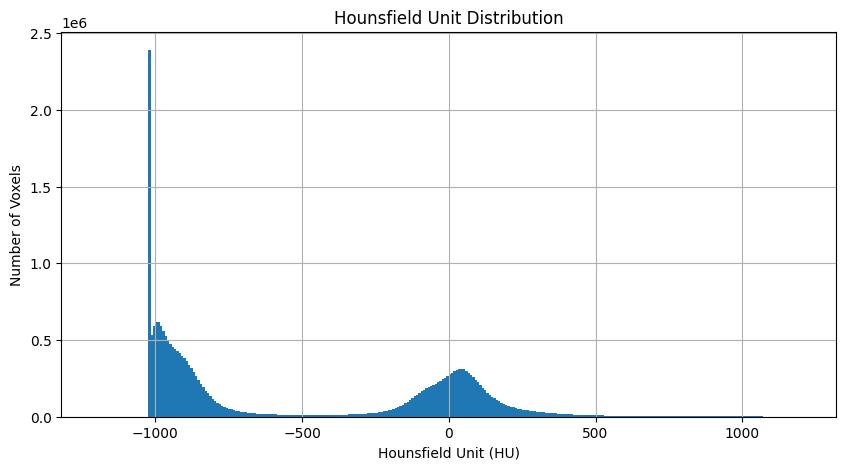

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/hu_histogram.png


In [11]:
# Plot HU histogram
plt.figure(figsize=(10, 5))

plt.hist(
    hu_values,
    bins=300,
    range=(-1200, 1200)
)

plt.title("Hounsfield Unit Distribution")
plt.xlabel("Hounsfield Unit (HU)")
plt.ylabel("Number of Voxels")

plt.grid(True)

output_path = FIGURES_DIR / "hu_histogram.png"

plt.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved figure: {output_path}")

## Step 7 — CT Windowing

A CT scan contains a very large range of Hounsfield Units.

Windowing maps a selected HU range to grayscale values, allowing different anatomical structures to become visible.

In this section we compare different CT windows.

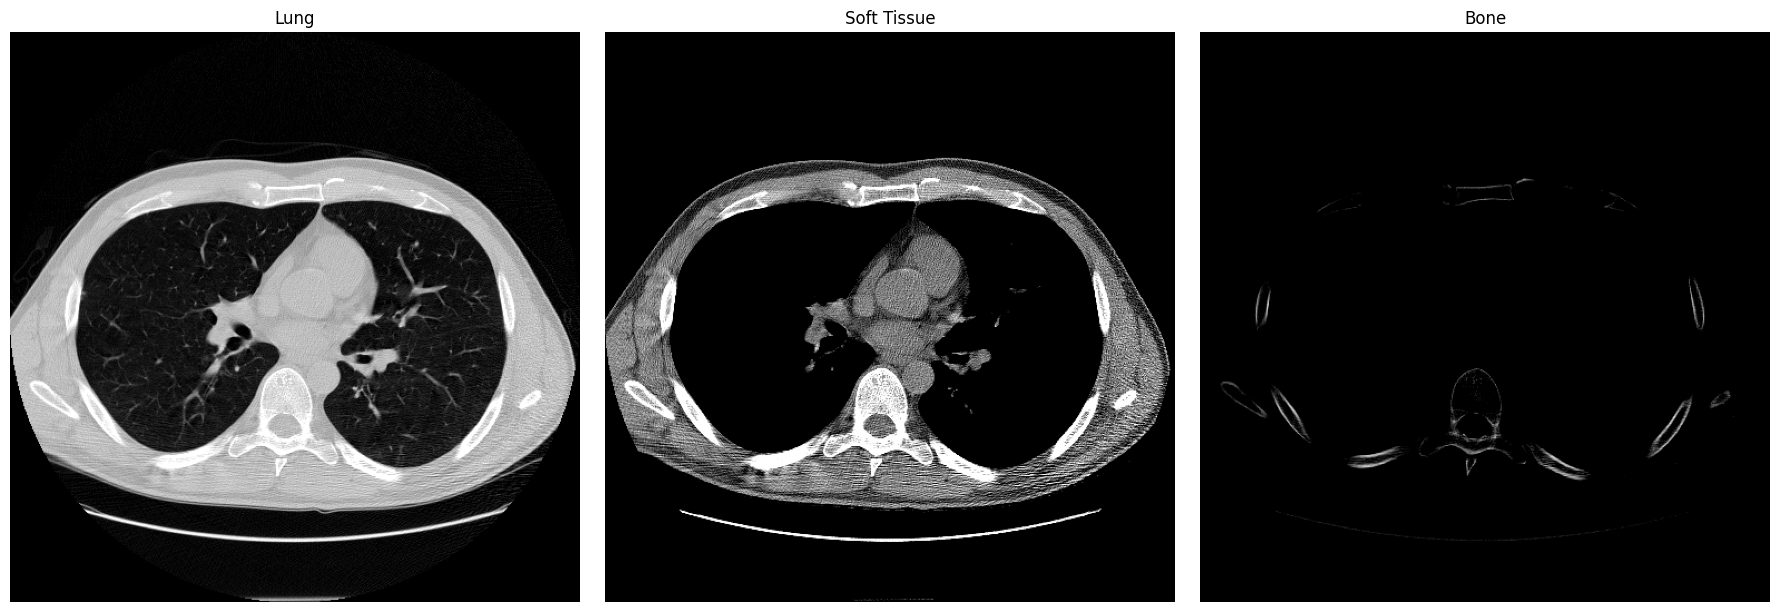

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/ct_windows.png


In [12]:
# Select middle slice
z = ct_array.shape[0] // 2
slice_2d = ct_array[z]

# Define commonly used CT windows
windows = [
    ("Lung", -1000, 400),
    ("Soft Tissue", -150, 250),
    ("Bone", 300, 1500),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (title, vmin, vmax) in zip(axes, windows):

    ax.imshow(
        slice_2d,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()

output_path = FIGURES_DIR / "ct_windows.png"

plt.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved figure: {output_path}")